# Temperatura em Modelos de Linguagem
### Como um único número controla criatividade vs determinismo

---

Após a tokenização, o modelo não escolhe o próximo token aleatoriamente — ele gera uma **distribuição de probabilidade** sobre todo o vocabulário.  
A **temperatura** é o parâmetro que reshapa essa distribuição antes da escolha acontecer.

Neste notebook vamos explorar:

1. A matemática por trás — **Softmax com temperatura**
2. Visualização — como a distribuição muda para diferentes valores de T
3. Simulação de geração de texto — vendo o efeito na prática sem API
4. *(Opcional)* Experimento com API real

> **Dependências:** `numpy`, `matplotlib` — sem necessidade de API key para as seções principais.

---

In [1]:
pip install numpy matplotlib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. A Matemática: Softmax com Temperatura

A função **Softmax** converte um vetor de scores (logits) em probabilidades que somam 1.  
A temperatura `T` é introduzida **dividindo os logits** antes do Softmax:

$$P(x_i) = \frac{e^{x_i / T}}{\sum_j e^{x_j / T}}$$

- `T < 1` → divide por número pequeno → logits ficam maiores → distribuição mais concentrada
- `T = 1` → comportamento padrão, sem alteração
- `T > 1` → divide por número grande → logits ficam menores → distribuição mais uniforme

Vamos implementar isso do zero:

In [2]:
import numpy as np

def softmax(logits, temperatura=1.0):
    """Softmax com temperatura. Temperatura=1.0 é o comportamento padrão."""
    logits_ajustados = np.array(logits) / temperatura
    exp_logits = np.exp(logits_ajustados - np.max(logits_ajustados))  # estabilidade numérica
    return exp_logits / exp_logits.sum()

# Simulando os logits de 6 tokens candidatos para completar:
# "O céu está..."
tokens_candidatos = ["azul", "nublado", "lindo", "escuro", "cor-de-rosa", "vazio"]
logits            = [4.5,    3.2,       2.8,     2.1,      0.9,           0.3]

print("Logits brutos (scores do modelo antes do Softmax):")
for token, logit in zip(tokens_candidatos, logits):
    print(f"  '{token}': {logit}")

print()
print("Probabilidades com T=1.0 (padrão):")
probs = softmax(logits, temperatura=1.0)
for token, prob in zip(tokens_candidatos, probs):
    print(f"  '{token}': {prob:.4f} ({prob*100:.1f}%)")

Logits brutos (scores do modelo antes do Softmax):
  'azul': 4.5
  'nublado': 3.2
  'lindo': 2.8
  'escuro': 2.1
  'cor-de-rosa': 0.9
  'vazio': 0.3

Probabilidades com T=1.0 (padrão):
  'azul': 0.6296 (63.0%)
  'nublado': 0.1716 (17.2%)
  'lindo': 0.1150 (11.5%)
  'escuro': 0.0571 (5.7%)
  'cor-de-rosa': 0.0172 (1.7%)
  'vazio': 0.0094 (0.9%)


## 2. Visualizando o Efeito da Temperatura

Agora vamos plotar como a **mesma distribuição de logits** se transforma para diferentes valores de temperatura.  
Esse é o gráfico central para entender o conceito.

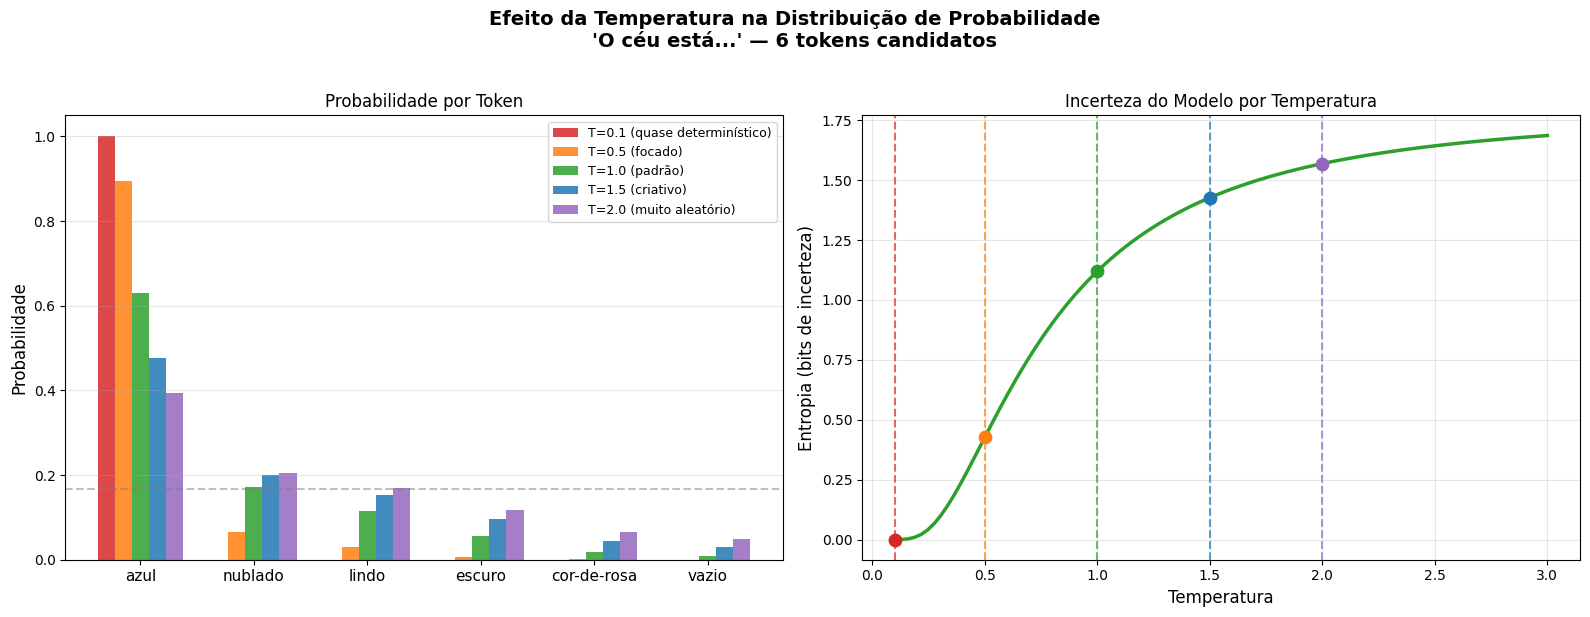

Gráfico salvo como 'temperatura_distribuicao.png'


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

temperaturas = [0.1, 0.5, 1.0, 1.5, 2.0]
cores        = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd"]
rotulos      = ["T=0.1 (quase determinístico)",
                "T=0.5 (focado)",
                "T=1.0 (padrão)",
                "T=1.5 (criativo)",
                "T=2.0 (muito aleatório)"]

x = np.arange(len(tokens_candidatos))
largura = 0.15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Efeito da Temperatura na Distribuição de Probabilidade\n'O céu está...' — 6 tokens candidatos",
             fontsize=14, fontweight="bold", y=1.02)

# --- Gráfico 1: Barras agrupadas ---
ax1 = axes[0]
for i, (temp, cor, rotulo) in enumerate(zip(temperaturas, cores, rotulos)):
    probs = softmax(logits, temperatura=temp)
    offset = (i - 2) * largura
    bars = ax1.bar(x + offset, probs, largura, label=rotulo, color=cor, alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(tokens_candidatos, fontsize=11)
ax1.set_ylabel("Probabilidade", fontsize=12)
ax1.set_title("Probabilidade por Token", fontsize=12)
ax1.legend(fontsize=9, loc="upper right")
ax1.set_ylim(0, 1.05)
ax1.axhline(y=1/len(tokens_candidatos), color="gray", linestyle="--",
            alpha=0.5, label="Distribuição uniforme")
ax1.grid(axis="y", alpha=0.3)

# --- Gráfico 2: Linha de entropia ---
ax2 = axes[1]
ts = np.linspace(0.1, 3.0, 100)
entropias = []
for t in ts:
    p = softmax(logits, temperatura=t)
    entropia = -np.sum(p * np.log(p + 1e-10))  # entropia de Shannon
    entropias.append(entropia)

ax2.plot(ts, entropias, color="#2ca02c", linewidth=2.5)
ax2.set_xlabel("Temperatura", fontsize=12)
ax2.set_ylabel("Entropia (bits de incerteza)", fontsize=12)
ax2.set_title("Incerteza do Modelo por Temperatura", fontsize=12)
ax2.grid(alpha=0.3)

for temp, cor in zip([0.1, 0.5, 1.0, 1.5, 2.0], cores):
    p = softmax(logits, temperatura=temp)
    e = -np.sum(p * np.log(p + 1e-10))
    ax2.axvline(x=temp, color=cor, linestyle="--", alpha=0.7)
    ax2.scatter([temp], [e], color=cor, zorder=5, s=80)

plt.tight_layout()
plt.savefig("temperatura_distribuicao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo como 'temperatura_distribuicao.png'")

**O que observar nos gráficos:**

- **Gráfico 1:** Com `T=0.1`, quase toda a probabilidade fica em `"azul"` — o modelo vai escolher esse token quase sempre. Com `T=2.0`, os outros candidatos ganham chance real de ser escolhidos.
- **Gráfico 2:** A entropia mede a **incerteza do modelo**. Temperatura baixa = baixa entropia = modelo confiante. Temperatura alta = alta entropia = modelo incerto/explorativo.

## 3. Simulando Geração de Texto

Vamos simular o processo de **sampling** — como o modelo escolhe tokens usando a distribuição com temperatura.  
Cada chamada gera uma sequência diferente porque fazemos uma amostragem probabilística.

In [4]:
import numpy as np

np.random.seed(None)  # sem seed fixo — cada execução é diferente

# Vocabulário simplificado com logits pré-definidos para cada posição
# Simula a escolha do próximo token em cada etapa da geração
etapas = [
    {
        "contexto": "O modelo de linguagem é",
        "candidatos": ["poderoso", "útil", "complexo", "simples", "revolucionário", "experimental"],
        "logits":     [4.2,        3.8,    3.1,        2.0,      1.5,               0.8]
    },
    {
        "contexto": "e pode ser usado para",
        "candidatos": ["gerar", "classificar", "resumir", "traduzir", "criar", "analisar"],
        "logits":     [4.0,     3.5,           3.3,       2.9,        2.1,     1.8]
    },
    {
        "contexto": "textos de forma",
        "candidatos": ["automática", "eficiente", "criativa", "precisa", "surpreendente", "inesperada"],
        "logits":     [4.5,          3.9,         2.5,        2.2,       1.0,              0.5]
    }
]

def gerar_sequencia(etapas, temperatura, n_geracoes=5):
    """Simula a geração de múltiplas sequências com uma dada temperatura."""
    resultados = []
    for _ in range(n_geracoes):
        tokens_escolhidos = []
        for etapa in etapas:
            probs = softmax(etapa["logits"], temperatura=temperatura)
            escolha = np.random.choice(etapa["candidatos"], p=probs)
            tokens_escolhidos.append(escolha)
        resultados.append(" ".join(tokens_escolhidos))
    return resultados

print("Frase base: 'O modelo de linguagem é ___ e pode ser usado para ___ textos de forma ___'")
print("=" * 70)

for temp in [0.1, 1.0, 2.0]:
    geracoes = gerar_sequencia(etapas, temperatura=temp)
    print(f"\nT={temp}:")
    for i, g in enumerate(geracoes, 1):
        print(f"  [{i}] O modelo de linguagem é {g}.")

Frase base: 'O modelo de linguagem é ___ e pode ser usado para ___ textos de forma ___'

T=0.1:
  [1] O modelo de linguagem é poderoso gerar automática.
  [2] O modelo de linguagem é poderoso gerar automática.
  [3] O modelo de linguagem é poderoso gerar automática.
  [4] O modelo de linguagem é poderoso gerar automática.
  [5] O modelo de linguagem é poderoso gerar automática.

T=1.0:
  [1] O modelo de linguagem é poderoso resumir eficiente.
  [2] O modelo de linguagem é útil analisar automática.
  [3] O modelo de linguagem é poderoso traduzir automática.
  [4] O modelo de linguagem é simples classificar criativa.
  [5] O modelo de linguagem é simples resumir automática.

T=2.0:
  [1] O modelo de linguagem é simples classificar automática.
  [2] O modelo de linguagem é complexo classificar eficiente.
  [3] O modelo de linguagem é útil gerar automática.
  [4] O modelo de linguagem é útil analisar precisa.
  [5] O modelo de linguagem é complexo resumir eficiente.


**O que observar:**

- Com `T=0.1`, as 5 gerações provavelmente produzem a **mesma frase** — o modelo é determinístico
- Com `T=1.0`, há variação mas as escolhas ainda fazem sentido
- Com `T=2.0`, tokens improváveis como `"experimental"` ou `"inesperada"` começam a aparecer com frequência

Execute a célula várias vezes — com `T=2.0` cada execução pode produzir combinações completamente diferentes.

## 4. Guia Prático: Qual Temperatura Usar?

| Faixa | Comportamento | Casos de uso |
|-------|--------------|-------------|
| `0.0 – 0.3` | Quase determinístico | Extração de dados, SQL, código, perguntas factuais |
| `0.3 – 0.7` | Focado e consistente | Resumos, classificação, análise técnica |
| `0.7 – 1.0` | Balanceado | Chatbots, assistentes gerais, explicações |
| `1.0 – 1.5` | Criativo | Brainstorming, escrita criativa, variações de copy |
| `1.5+`       | Muito aleatório | Exploração experimental — raramente útil em produção |

## 5. *(Opcional)* Experimento com API Real

> ⚠️ **Esta seção requer uma API key da Anthropic.**  
> Se não tiver acesso, todas as conclusões já foram demonstradas nas seções anteriores.
> Para ativar: instale o SDK com `pip install anthropic` e defina sua chave abaixo.

O objetivo aqui é confirmar empiricamente o que simulamos — usando um modelo real.

In [ ]:
# !pip install anthropic -q

# import anthropic
# import os

# client = anthropic.Anthropic(api_key="SUA_CHAVE_AQUI")

# prompt = "Complete a frase com apenas 1 palavra: 'A inteligência artificial vai'"

# for temperatura in [0.1, 1.0, 2.0]:
#     respostas = []
#     for _ in range(5):  # 5 chamadas por temperatura
#         resposta = client.messages.create(
#             model="claude-sonnet-4-20250514",
#             max_tokens=20,
#             temperature=temperatura,
#             messages=[{"role": "user", "content": prompt}]
#         )
#         respostas.append(resposta.content[0].text.strip())

#     unicos = len(set(respostas))
#     print(f"\nT={temperatura} → {respostas}")
#     print(f"  Respostas únicas: {unicos}/5")

## 6. Conclusões

---

**O que aprendemos neste notebook:**

**Sobre a matemática:**
- Temperatura divide os logits antes do Softmax — é uma operação simples com efeito profundo
- Temperatura baixa concentra probabilidade no token mais provável
- Temperatura alta nivela a distribuição, dando chance a tokens menos prováveis
- Entropia de Shannon mede quantitativamente o grau de incerteza da distribuição

**Sobre o uso prático:**
- Temperatura não afeta o *conhecimento* do modelo — apenas *como ele escolhe* entre o que sabe
- Para aplicações de produção, valores entre 0.2 e 0.7 são os mais comuns
- Temperatura alta não torna o modelo mais inteligente — só mais imprevisível

**Conexão com os outros conceitos:**
- Os tokens gerados aqui são exatamente os tokens que estudamos na aula de **tokenização**
- Os logits que o modelo gera antes do Softmax são derivados dos **embeddings** — próximo notebook

---

### Próximo passo: Embeddings
Como os IDs de tokens viram vetores com significado semântico — e como medir similaridade entre conceitos.